In [1]:
import math
import time
from enum import Enum, auto
# my utils
from utils import *

import cv2
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(precision=4)

from filterpy.common import Saver 

# Mac screen info
from AppKit import NSScreen
SCREEN_INDEX = 0
SCREEN_WIDTH, SCREEN_HIGHT = NSScreen.screens()[SCREEN_INDEX].frame().size.width, NSScreen.screens()[SCREEN_INDEX].frame().size.height
print(f'screen size: {(SCREEN_WIDTH, SCREEN_HIGHT)}')

# how to control your mouse: https://stackoverflow.com/questions/281133/how-to-control-the-mouse-in-mac-using-python
# mouse controll: https://pypi.org/project/pynput/
from pynput import mouse as Mouse

# hand landmark: https://google.github.io/mediapipe/solutions/hands.html
import mediapipe as mp 
mp_drawing = mp.solutions.drawing_utils
mp_hands = mp.solutions.hands

screen size: (1920.0, 1200.0)


In [2]:
def draw_handedness(img, handedness):
  if handedness[0] < 0.5:
    label = 'Left' 
  elif handedness[0] > 0.5:
    label = 'Right' 
  else:
    label = 'Unknown'

  img_w, img_h = img.shape[1], img.shape[0]
  cv2.putText(img, f'{label} {np.abs((handedness[0]-.5)*2) :.2f}',
      org=(img_w//2 - 200, 30), # LeftBottomCornerOfText
      fontFace=cv2.FONT_HERSHEY_SIMPLEX, 
      fontScale=1,
      color=(0, 0, 255),
      lineType=2)

def draw_landmarks(img, landmarks, color=(50, 255, 50)):
  img_w, img_h = img.shape[1], img.shape[0]
  # draw dot
  for i in range(21):
    p = landmarks[i, 0:2, 0]
    cv2.circle(img, p.astype(int), radius=4, thickness=-1, color=(50, 50, 255))

  # draw line 
  pairs = []
  # wrist to index~pinky
  pairs.append((0, 1))
  pairs.append((0, 5))
  pairs.append((0, 17))
  # finger to finger
  pairs.append((5, 9))
  pairs.append((9, 13))
  pairs.append((13, 17))
  # mcp to tip
  for i in range(1, 21, 4):
    for j in range(3):
      pairs.append((i+j, i+j+1))

  for pp1, pp2 in pairs:
    p1 = landmarks[pp1, 0:2, 0]
    p2 = landmarks[pp2, 0:2, 0]
    cv2.line(img, p1.astype(int), p2.astype(int), thickness=2, color=color)

def draw_finger_state(img, handedness, finger_states):
  img_w, img_h = img.shape[1], img.shape[0]

  state_str = ''
  for finger_idx in range(5): 
    if handedness[0] < 0.5:
      state_str = f'{finger_states[finger_idx].value}{state_str}'
    else:
      state_str = f'{state_str}{finger_states[finger_idx].value}'      
  cv2.putText(img, state_str,
      org=(img_w//2, 30), # bottomLeftCornerOfText
      fontFace=cv2.FONT_HERSHEY_SIMPLEX, 
      fontScale=1,
      color=(0, 0, 255),
      lineType=2)


In [3]:
DESIRED_HEIGHT = 720
DESIRED_WIDTH = 720
def preprocess_img(image):
  h, w = image.shape[:2]
  # resize
  if h < w:
    img = cv2.resize(image, (DESIRED_WIDTH, math.floor(h/(w/DESIRED_WIDTH))))
  else:
    img = cv2.resize(image, (math.floor(w/(h/DESIRED_HEIGHT)), DESIRED_HEIGHT))

  return img

def landmarks2vec(hand_landmarks):
  vecs = np.empty((21, 3))
  for landmark_idx in mp_hands.HandLandmark:
    vecs[landmark_idx] = np.array([
      hand_landmarks.landmark[landmark_idx].x,
      hand_landmarks.landmark[landmark_idx].y,
      hand_landmarks.landmark[landmark_idx].z,
    ])
  return vecs

In [4]:
def switch_hand(landmarks):
  landmarks = np.array(landmarks)
  landmarks[[1, 2, 3, 4, 5, 6, 7, 8]] = landmarks[[17, 18, 19, 20, 13, 14, 15, 16]] 
  return landmarks 

In [5]:
def shift_to_palm_coordinate(landmarks, is_right_hand):
  """
  origin: wrist
  y-axis: index-mcp to wrist vector
  z-axis: orthogonal to y-axis vector and wrist pinky-mcp vector, point out of palm 
  @return shifted_landmarks, rotation_matrix
  """
  landmarks = np.array(landmarks)

  # shift origin
  delta_origin = np.copy(landmarks[0])
  landmarks -= delta_origin 

  # calculate rotation martix
  axis_y = landmarks[5] - landmarks[0]
  axis_z = np.cross(landmarks[9] - landmarks[0], axis_y)
  # correct z-axis direction
  axis_z = axis_z if is_right_hand else -axis_z
  r = get_coordinate_rotation_matrix([-axis_y, -axis_z], [[0,1,0], [0,0,1]])
  
  return landmarks @ r, r,delta_origin 


def shift_back_to_origin_coordinate(landmarks, rotation_matrix, delta_origin):
  landmarks = np.array(landmarks)

  # rotate back
  # NOTE: invsere of rotation martix = transpose of rotation matrix
  landmarks = landmarks @ rotation_matrix.T
  
  # shift origin
  landmarks += delta_origin
  
  return landmarks


def annotate_3axis(img, rotation_matrix, delta_origin):
  start = shift_back_to_origin_coordinate([0,0,0], rotation_matrix, delta_origin)
  x_end = shift_back_to_origin_coordinate([40,0,0], rotation_matrix, delta_origin)
  y_end = shift_back_to_origin_coordinate([0,40,0], rotation_matrix, delta_origin)
  z_end = shift_back_to_origin_coordinate([0,0,40], rotation_matrix, delta_origin)
  cv2.arrowedLine(img, (start[0:2]).astype(int), (x_end[0:2]).astype(int), thickness=2, color=(0, 0, 255))
  cv2.arrowedLine(img, (start[0:2]).astype(int), (y_end[0:2]).astype(int), thickness=2, color=(0, 255, 0))
  cv2.arrowedLine(img, (start[0:2]).astype(int), (z_end[0:2]).astype(int), thickness=2, color=(255, 0, 0))
  cv2.putText(img, 'x', org=((x_end[0:2] + [5,5]).astype(int)), color=(0, 0, 255), fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=.7, lineType=2)
  cv2.putText(img, 'y', org=((y_end[0:2] + [5,5]).astype(int)), color=(0, 255, 0), fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=.7, lineType=2)
  cv2.putText(img, 'z', org=((z_end[0:2] + [5,5]).astype(int)), color=(255, 0, 0), fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=.7, lineType=2)

In [6]:
class FINGER_STATE(Enum):
  BENT = 0
  STRAIGHT = 1
  UNKNOWN = auto()

class FINGER(Enum):
  THUMB = 0
  INDEX = 1
  MIDDLE = 2
  RING = 3
  PINKY = 4


def get_finger_state(landmarks):
  # TODO: detect thumb state
  res = np.array([FINGER_STATE.UNKNOWN for i in range(5)])
  
  # finger_idx
  # thumb: 1~4, index: 5~8, middle: 9~12, ring: 13~16, pinky: 17~20
  for finger_idx in range(1, 21, 4):
    tip = landmarks[finger_idx+3, :, 0]
    dip = landmarks[finger_idx+2, :, 0]
    pip = landmarks[finger_idx+1, :, 0]
    mcp = landmarks[finger_idx, :, 0]

    accumulated_angle = (np.pi - angle_between_vectors(pip - mcp, pip - dip)) + (np.pi - angle_between_vectors(dip - pip, dip - tip))
    
    if accumulated_angle > (np.pi * 0.4):
      res[(finger_idx-1) // 4] = FINGER_STATE.BENT
    else:
      res[(finger_idx-1) // 4] = FINGER_STATE.STRAIGHT

  return res

In [7]:
def get_landmarks_Q_ratio():
  return np.array(([
    [0.3029, 0.288 , 0.0001],
    [0.3697, 0.3071, 0.2132],
    [0.4982, 0.341 , 0.3471],
    [0.6223, 0.3485, 0.4628],
    [0.7401, 0.3523, 0.6022],
    [0.5629, 0.325 , 0.444 ],
    [0.725 , 0.3822, 0.6111],
    [0.8593, 0.5839, 0.7724],
    [1.    , 0.9228, 0.9337],
    [0.5521, 0.2954, 0.4395],
    [0.697 , 0.3602, 0.6971],
    [0.7584, 0.6306, 0.8509],
    [0.8241, 1.    , 1.    ],
    [0.5265, 0.2729, 0.4513],
    [0.6577, 0.3198, 0.6869],
    [0.7236, 0.4839, 0.7723],
    [0.7885, 0.6997, 0.8584],
    [0.4793, 0.2586, 0.4784],
    [0.5691, 0.2762, 0.6415],
    [0.6267, 0.3144, 0.7468],
    [0.6858, 0.3841, 0.8618]]
  ))

In [8]:
mouse = Mouse.Controller()
# mouse_listener = Mouse.Listener(
#   on_move=lambda x,y: print(f'Pointer move to ({x :.2f}, {y :.2f})'),
#   on_scroll=lambda x,y,dx,dy: print(f'Scrolled ({x :.2f}, {y :.2f}) at {"down" if dy < 0 else "up"}'))
# mouse_listener.start()
# mouse_listener.wait()

# fps
s_time = time.time()
frame_cnt = 0
prev_frame_cnt = 0
prev_timestamp = time.time()

# init estimate
existence = [.5, 0]
handedness = [.5, 0]
landmarks = np.full((21, 3, 2), 0.5)

# filter
dt = 1./15
existence_f = pos_vel_filter(existence, P=.5, R=.5, Q=.001, dt=1.)
handedness_f = pos_vel_filter(handedness, P=.5, R=.1, Q=.01, dt=1.)

pos_Q = np.tile([.25, .25, 1.25], [21, 1])
vel_Q = get_landmarks_Q_ratio() * [52.5, 54., 12.5]
ls_Q = np.eye(126) * np.stack([pos_Q, vel_Q], axis=2).flatten()
# x_Q = np.eye(2) * [.2, 40.]
# y_Q = np.eye(2) * [.25, 90.]
# z_Q = np.eye(2) * [1.2, 40.]
# ls_Q = np.eye(126, 126) * (np.column_stack([np.full((21,1), .2), prior_std[:, 0, 1], np.full((21,1), .25), prior_std[:, 1, 1], np.full((21,1), 1.2), prior_std[:, 2, 1]]).flatten())
# ls_Q_block = np.block([[x_Q, np.zeros((2,4))], [np.zeros((2,2)), y_Q, np.zeros((2,2))], [np.zeros((2,4)), z_Q]])
# ls_Q = block_diagonal_array(126//6, ls_Q_block)
x_R = .25
y_R = .25
z_R = .75 
ls_R_block = np.eye(3) * [x_R, y_R, z_R]
ls_R = block_diagonal_array(63//3, ls_R_block)
landmarks_f = multi_pos_vel_filter(landmarks.flatten(), P=DESIRED_WIDTH, R=ls_R, Q=ls_Q, dt=dt)
landmarks_s = Saver(landmarks_f)

# gesture

# DEBUG: params
tmax = -100


cap = cv2.VideoCapture(0)
with mp_hands.Hands(
    min_detection_confidence=0.75,
    min_tracking_confidence=0.7) as hands:
  while cap.isOpened():
    success, raw_image = cap.read()
    if not success:
      print("Ignoring empty camera frame.")
      # If loading a video, use 'break' instead of 'continue'.
      continue

    # Flip the image horizontally for a later selfie-view display, and convert the BGR image to RGB.
    image = cv2.cvtColor(cv2.flip(preprocess_img(raw_image), 1), cv2.COLOR_BGR2RGB)
    # To improve performance, optionally mark the image as not writeable to pass by reference.
    image.flags.writeable = False
    results = hands.process(image)
    
    image_hight, image_width, _ = image.shape
    # Draw the hand annotations on the image.
    image.flags.writeable = True
    annotated_image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)


    # existence detection
    if results.multi_hand_landmarks:
      z_existence = 1
    else :
      z_existence = 0
    existence_f.predict()
    existence_f.update(z_existence)
    existence = existence_f.x
      

    if existence[0] > 0.5:

      handedness_f.predict()
      landmarks_f.predict()

      if z_existence == 1:
        # NOTE: `existence` only response for one hand existence
        raw_handedness, raw_landmarks = results.multi_handedness[0], results.multi_hand_landmarks[0]

        # update handedness 
        z_handedness = .5 + raw_handedness.classification[0].score * (.5 if raw_handedness.classification[0].index == 1 else -.5)
        handedness_f.update(z_handedness)

        # preprocess z_landmarks
        z_landmarks = landmarks2vec(raw_landmarks)

        # switch hand landmarks
        should_switch_hand = (handedness[0] > 0.5 and z_handedness < 0.5) or (handedness[0] < 0.5 and z_handedness > 0.5)
        if should_switch_hand: 
          z_landmarks = switch_hand(z_landmarks)

        # scale to image size
        z_landmarks *= [image_width, image_hight, image_width] 

        # change coordinate
        # z_shift_landmarks, rotation_matrix, delta_origin = shift_to_palm_coordinate(z_landmarks, handedness[0] > 0.5) 
        # landmarks_f.update(z_shift_landmarks.flatten())
        
        # update landmarks
        landmarks_f.update(z_landmarks.flatten())
        
        # save landmarks
        # if time.time() - s_time > 3:
          # landmarks_s.save()

      handedness = handedness_f.x
      landmarks = landmarks_f.x.reshape(21, 3, 2)


      # Gesture
      finger_states = get_finger_state(landmarks)

      ## move mouse
      # """
      if np.all(finger_states[[2,3]] == FINGER_STATE.BENT) and (
            (np.all(np.abs(landmarks[0, 0:2, 1]) < 10.))
            or 
            (finger_states[1] == FINGER_STATE.STRAIGHT)
          ):

        max_move_speed = 100
        x = np.clip(landmarks[8, 0, 1] , -max_move_speed, max_move_speed)
        y = np.clip(landmarks[8, 1, 1] , -max_move_speed, max_move_speed)

        # WARN: mouse may move to the negative position, which refer to second monitor 
        # clip mouse position in the "main monitor"
        # FUTURE: support multi-monitor
        move_x = np.clip(x, 0 - mouse.position[0], SCREEN_WIDTH - mouse.position[0])
        move_y = np.clip(y, 0 - mouse.position[1], SCREEN_HIGHT - mouse.position[1])
        mouse.move(move_x, move_y)
      # """

      # ## scroll vertical
      # # TODO: smooth scroll (keep scroll after gesture disappear)

      # ## scroll up 
      max_scroll_speed = 5
      scale_factor = .07
      if np.all(finger_states[[4]] == FINGER_STATE.BENT) and \
            np.all(finger_states[[1,2,3]] == FINGER_STATE.STRAIGHT):
        scroll_y = np.clip(-landmarks[8, 1, 1]*scale_factor, 0, max_scroll_speed)
        mouse.scroll(0, scroll_y)
        # annotate
        cv2.arrowedLine(annotated_image, landmarks[8, 0:2, 0].astype(int), (landmarks[8, 0:2, 0] + [0, -scroll_y*10]).astype(int), color=(255, 50, 50), thickness=3)

      # ## scroll down
      if np.all(finger_states[[3,4]] == FINGER_STATE.BENT) and \
            np.all(finger_states[[1,2]] == FINGER_STATE.STRAIGHT):
        scroll_y = np.clip(landmarks[8, 1, 1]*scale_factor, -max_scroll_speed, 0)
        mouse.scroll(0, scroll_y)
        # annotate
        cv2.arrowedLine(annotated_image, landmarks[8, 0:2, 0].astype(int), (landmarks[8, 0:2, 0] + [0, -scroll_y*10]).astype(int), color=(255, 50, 50), thickness=3)

      ## switch desktop
      ## switch screen


      # Draw 
      # measurement landmarks
      # mp_drawing.draw_landmarks(annotated_image, raw_landmarks, mp_hands.HAND_CONNECTIONS)
      # draw_landmarks(annotated_image, np.stack([z_landmarks, np.zeros(z_landmarks.shape)], axis=2), (255, 50, 50, 0.5))

      # Draw normal landmark
      draw_handedness(annotated_image, handedness)

      # Draw projected landmarks
      # inv_landmarks = np.stack([
        # shift_back_to_origin_coordinate(landmarks[:, :, 0], rotation_matrix, delta_origin), 
        # shift_back_to_origin_coordinate(landmarks[:, :, 1], rotation_matrix, delta_origin)], axis=2)
      # Draw projection axis
      # annotate_3axis(annotated_image, rotation_matrix, delta_origin)      

      # Draw handedness
      draw_landmarks(annotated_image, landmarks)

      # Drw finger states
      draw_finger_state(annotated_image, handedness, finger_states)
      

      # DEBUG: output 
      # if time.time() - s_time > 1:
        # tmax = np.max([tmax, np.abs(landmarks_s.z[-1].reshape(21,3)[8, 2] - landmarks_s.z[-2].reshape(21,3)[8, 2]) / dt])
      # tmax = np.max([tmax, np.abs(landmarks_f.x.reshape(21,3,2)[8,2,1])])
        # cv2.putText(annotated_image, 
            #  f'{landmarks_f.x.reshape(21,3,2)[8,1,1] :.2f}',
            #  f'{time.time() % 20}',
            #  org=(int(image_width*.01), int(image_hight*.15)), # bottomLeftCornerOfText
            #  fontFace=cv2.FONT_HERSHEY_SIMPLEX, 
            #  fontScale=.8,
            #  color=(255, 255, 255),
            #  lineType=2)

    else: 
      pass

    # Draw fps
    frame_cnt += 1
    now_timestamp = time.time()
    if now_timestamp - prev_timestamp >= 1:
      prev_timestamp, prev_frame_cnt = now_timestamp, frame_cnt
      frame_cnt = 0
    cv2.putText(annotated_image, f'{prev_frame_cnt}', org=(image_width - 30, 20), fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=0.5, color=(100, 255, 100), lineType=2)


    cv2.imshow('Hands', annotated_image)
    if cv2.waitKey(20) & 0xFF == 27:
      # FIXME: `Listener.stop()` failed to stop mouse listerner
      # mouse_listener.stop()
      break

cap.release()
# cv2.destroyAllWindows()

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## Testing

In [ ]:
zs = np.asanyarray(landmarks_s.z).reshape(-1, 21, 3)#[:-1]
prior = np.asanyarray(landmarks_s.x_prior).reshape(-1, 21, 3, 2)#[1:]
post = np.asanyarray(landmarks_s.x_post).reshape(-1, 21, 3, 2)
ts = np.arange(zs.shape[0]) * dt
print(ts.shape)

(873,)


Text(0.5, 1.0, 'z vel')

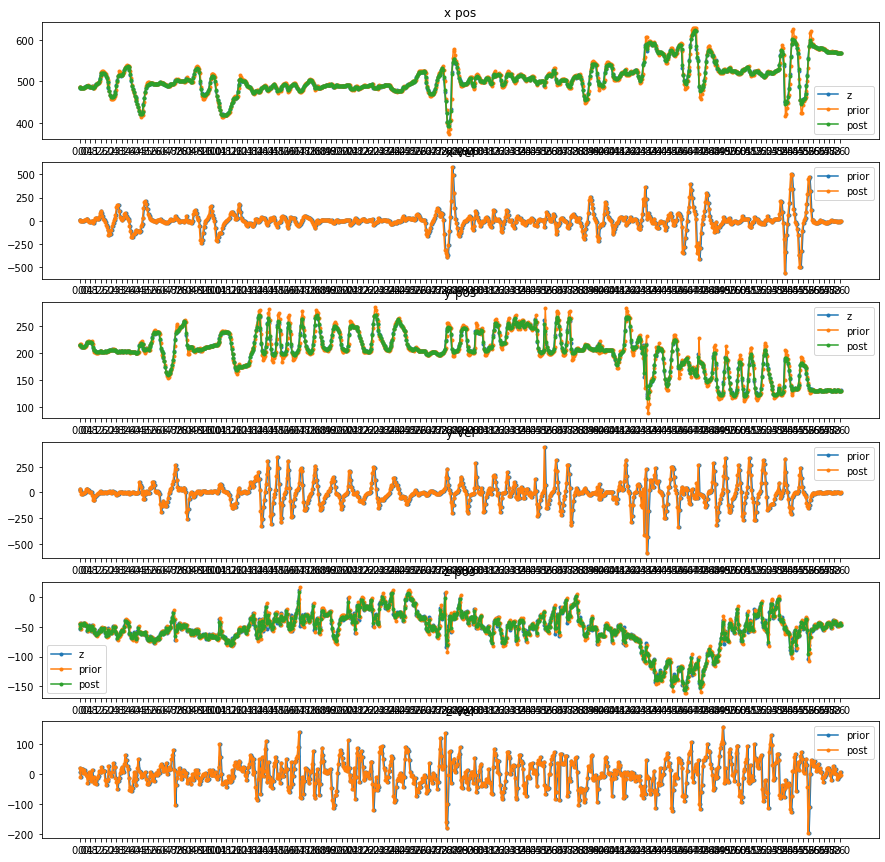

In [ ]:
plt.figure(figsize=(15, 15))
# yv: 100
idx = 8
xyz = 1
start = 0
end = -1

plt.subplot(611)
plt.plot(ts[start:end], zs[start:end, idx, 0], marker='.', label='z')
plt.plot(ts[start:end], prior[start:end, idx, 0, 0], marker='.', label='prior')
plt.plot(ts[start:end], post[start:end, idx, 0, 0], marker='.', label='post')

plt.xticks(np.arange(zs.shape[0]*dt, step=6*dt))
plt.legend(loc='best')
plt.title('x pos')

plt.subplot(612)
plt.plot(ts[start:end], prior[start:end, idx, 0, 1], marker='.', label='prior')
plt.plot(ts[start:end], post[start:end, idx, 0, 1], marker='.', label='post')

plt.xticks(np.arange(zs.shape[0]*dt, step=6*dt))
plt.legend(loc='best')
plt.title('x vel')

plt.subplot(613)
plt.plot(ts[start:end], zs[start:end, idx, 1], marker='.', label='z')
plt.plot(ts[start:end], prior[start:end, idx, 1, 0], marker='.', label='prior')
plt.plot(ts[start:end], post[start:end, idx, 1, 0], marker='.', label='post')

plt.xticks(np.arange(zs.shape[0]*dt, step=6*dt))
plt.legend(loc='best')
plt.title('y pos')

plt.subplot(614)
plt.plot(ts[start:end], prior[start:end, idx, 1, 1], marker='.', label='prior')
plt.plot(ts[start:end], post[start:end, idx, 1, 1], marker='.', label='post')

plt.xticks(np.arange(zs.shape[0]*dt, step=6*dt))
plt.legend(loc='best')
plt.title('y vel')

plt.subplot(615)
plt.plot(ts[start:end], zs[start:end, idx, 2], marker='.', label='z')
plt.plot(ts[start:end], prior[start:end, idx, 2, 0], marker='.', label='prior')
plt.plot(ts[start:end], post[start:end, idx, 2, 0], marker='.', label='post')

plt.xticks(np.arange(zs.shape[0]*dt, step=6*dt))
plt.legend(loc='best')
plt.title('z pos')

plt.subplot(616)
plt.plot(ts[start:end], prior[start:end, idx, 2, 1], marker='.', label='prior')
plt.plot(ts[start:end], post[start:end, idx, 2, 1], marker='.', label='post')

plt.xticks(np.arange(zs.shape[0]*dt, step=6*dt))
plt.legend(loc='best')
plt.title('z vel')

In [ ]:
zs_std = np.std(zs, axis=0)
zs_mean = np.mean(zs, axis=0)
prior_std = np.std(prior, axis=0)
prior_mean = np.mean(prior, axis=0)
post_std = np.std(post, axis=0)
post_mean = np.mean(post, axis=0)
print(zs_std.shape, prior_std.shape, post_std.shape)

(21, 3) (21, 3, 2) (21, 3, 2)


(21, 3)


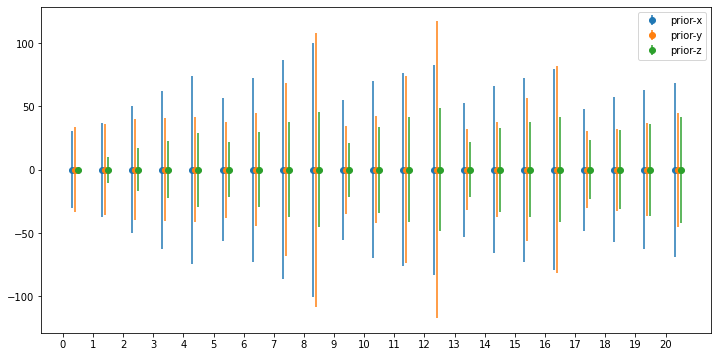

In [ ]:
plt.figure(figsize=(12, 6))
# plt.errorbar(np.arange(21)+.0, np.zeros(21), yerr=zs_std[:, 0], linestyle='None', fmt='o', label='x')
# plt.errorbar(np.arange(21)+.1, np.zeros(21), yerr=zs_std[:, 1], linestyle='None', fmt='o', label='y')
# plt.errorbar(np.arange(21)+.2, np.zeros(21), yerr=zs_std[:, 2], linestyle='None', fmt='o', label='z')
plt.errorbar(np.arange(21)+.3, np.zeros(21), yerr=prior_std[:, 0, 1], linestyle='None', fmt='o', label='prior-x')
plt.errorbar(np.arange(21)+.4, np.zeros(21), yerr=prior_std[:, 1, 1], linestyle='None', fmt='o', label='prior-y')
plt.errorbar(np.arange(21)+.5, np.zeros(21), yerr=prior_std[:, 2, 1], linestyle='None', fmt='o', label='prior-z')
# plt.errorbar(np.arange(21)+.6, np.zeros(21), yerr=post_std[:, 0, 1], linestyle='None', fmt='o', label='post-x')
# plt.errorbar(np.arange(21)+.7, np.zeros(21), yerr=post_std[:, 1, 1], linestyle='None', fmt='o', label='post-y')
# plt.errorbar(np.arange(21)+.8, np.zeros(21), yerr=post_std[:, 2, 1], linestyle='None', fmt='o', label='post-z')
plt.xticks(np.arange(21))
plt.legend()
# print(np.std(zs_std[:, :], axis=0))
print(prior_std[:, :, 1].shape)

[[ 30.416  33.72    0.004]
 [ 37.128  35.964  10.348]
 [ 50.04   39.934  16.846]
 [ 62.494  40.81   22.463]
 [ 74.324  41.25   29.228]
 [ 56.529  38.055  21.553]
 [ 72.811  44.757  29.66 ]
 [ 86.301  68.368  37.492]
 [100.432 108.063  45.318]
 [ 55.447  34.595  21.332]
 [ 70.005  42.184  33.836]
 [ 76.169  73.839  41.302]
 [ 82.765 117.097  48.537]
 [ 52.873  31.953  21.903]
 [ 66.052  37.448  33.342]
 [ 72.673  56.659  37.483]
 [ 79.195  81.935  41.665]
 [ 48.142  30.278  23.218]
 [ 57.153  32.347  31.136]
 [ 62.94   36.812  36.249]
 [ 68.871  44.974  41.831]]


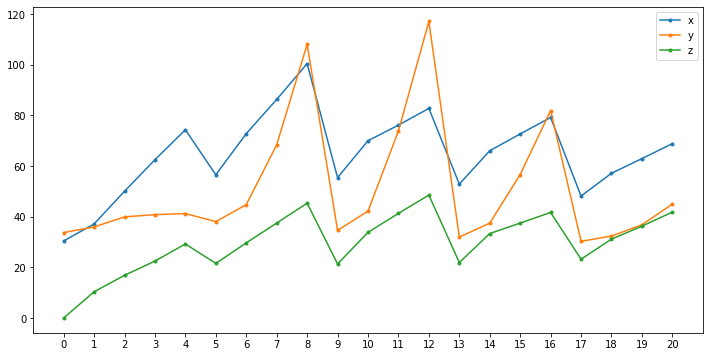

In [ ]:
plt.figure(figsize=(12,6))
np.set_printoptions(suppress=True)
print(np.round(prior_std[:, :, 1], 3))
plt.plot(np.arange(21), prior_std[:, 0, 1], marker='.', label='x')
plt.plot(np.arange(21), prior_std[:, 1, 1], marker='.', label='y')
plt.plot(np.arange(21), prior_std[:, 2, 1], marker='.', label='z')
plt.xticks(np.arange(21))
plt.legend()
plt.show()

[[0.3029 0.288  0.0001]
 [0.3697 0.3071 0.2132]
 [0.4982 0.341  0.3471]
 [0.6223 0.3485 0.4628]
 [0.7401 0.3523 0.6022]
 [0.5629 0.325  0.444 ]
 [0.725  0.3822 0.6111]
 [0.8593 0.5839 0.7724]
 [1.     0.9228 0.9337]
 [0.5521 0.2954 0.4395]
 [0.697  0.3602 0.6971]
 [0.7584 0.6306 0.8509]
 [0.8241 1.     1.    ]
 [0.5265 0.2729 0.4513]
 [0.6577 0.3198 0.6869]
 [0.7236 0.4839 0.7723]
 [0.7885 0.6997 0.8584]
 [0.4793 0.2586 0.4784]
 [0.5691 0.2762 0.6415]
 [0.6267 0.3144 0.7468]
 [0.6858 0.3841 0.8618]]


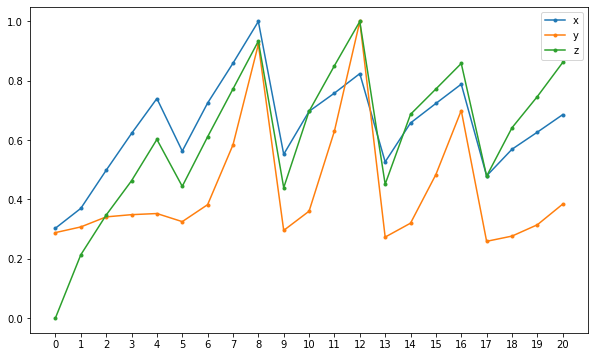

In [ ]:
max_v = np.max(prior_std[:,:,1], axis=0)

# print(max_v)
ratio = np.round(prior_std[:,:,1]/max_v, 4)
print(ratio)

plt.figure(figsize=(10,6))
plt.plot(np.arange(21), ratio[:, 0], marker='.', label='x')
plt.plot(np.arange(21), ratio[:, 1], marker='.', label='y')
plt.plot(np.arange(21), ratio[:, 2], marker='.', label='z')
plt.xticks(np.arange(21))
plt.legend()
plt.show()

In [ ]:
# a = np.arange(12).reshape(3,4)
# b = np.linspace(0.5, 6, 12).reshape(3,4)
# print(a, b)
# print(np.stack([a,b],axis=2).flatten())
np.repeat([.2, .25, 1.2], [3, 3 ,3])

array([0.2 , 0.2 , 0.2 , 0.25, 0.25, 0.25, 1.2 , 1.2 , 1.2 ])